In [1]:
import os
import cv2
import time
import signal
import threading
import numpy as np
import pyzed.sl as sl
import matplotlib.pyplot as plt

### Record videos

In [2]:
zed_list = []
current_images = []
current_timestamps = []
thread_list = []
stop_signal = False




def signal_handler(signal, frame):
    global stop_signal
    stop_signal=True
    time.sleep(0.5)
    exit()

def grab_run(index):
    global stop_signal
    global zed_list
    global current_timestamps
    global current_images
    global name_list

    

    runtime = sl.RuntimeParameters()
    while not stop_signal:

        err = zed_list[index].grab(runtime)
        if err == sl.ERROR_CODE.SUCCESS:

            zed_list[index].retrieve_image(current_images[index], sl.VIEW.LEFT)
            current_timestamps[index] = zed_list[index].get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns #time of function call


        barrier.wait()

        time.sleep(0.001) #1ms
    zed_list[index].disable_recording()
    zed_list[index].close()

def main():
    global stop_signal
    global zed_list
    global current_images
    global current_timestamps
    global thread_list
    global name_list
    global barrier
    signal.signal(signal.SIGINT, signal_handler)

    output_file_names = ['multicam_1.svo2','multicam_2.svo2']

    print("Running...")
    init = sl.InitParameters()
    init.camera_resolution = sl.RESOLUTION.SVGA
    init.camera_fps = 120  # The framerate is lowered to avoid any USB3 bandwidth issues
    init.async_image_retrieval = False


    #List and open cameras
    name_list = []
    last_ts_list = []
    cameras = sl.Camera.get_device_list()

    index = 0
    for cam in cameras:
        init.set_from_serial_number(cam.serial_number) # define input source
        name_list.append(f"ZED_{cam.serial_number}")

        print(f"Opening {name_list[index]}")
        zed_list.append(sl.Camera())
        current_images.append(sl.Mat())
        current_timestamps.append(0)
        last_ts_list.append(0)

        # open cameras
        status = zed_list[index].open(init)
        if status != sl.ERROR_CODE.SUCCESS:
            print(repr(status))
            zed_list[index].close()

        # set recording params
        recording_param = sl.RecordingParameters(
            os.path.join('./', output_file_names[index]),
            sl.SVO_COMPRESSION_MODE.H264) # Enable recording with the filename specified in argument
        err = zed_list[index].enable_recording(recording_param)
        index = index +1

        if err != sl.ERROR_CODE.SUCCESS:
            print("Recording ZED : ", err)
            exit(1)

    num_threads = len(zed_list)
    barrier = threading.Barrier(num_threads)

    #Start camera threads
    for index in range(0, len(zed_list)):
        if zed_list[index].is_opened():
            thread_list.append(threading.Thread(target=grab_run, args=(index,)))
            thread_list[index].start()
    
    #Display camera images
    key = ''
    while key != 113:  # for 'q' key
        for cam_index in range(0, len(zed_list)):
            if zed_list[cam_index].is_opened():

                # if there is a new frame 
                if (current_timestamps[cam_index] >= last_ts_list[cam_index]):
                    img = current_images[cam_index].get_data()

                    img = cv2.circle(img,(960,540),10,(0,0,255),3)
                    
                    cv2.imshow(name_list[cam_index], cv2.resize(img,(600,400)))

                    # set the last timestamp for each cam to the CURRENT_ts one of each cam 
                    last_ts_list[cam_index] = current_timestamps[cam_index]

        key = cv2.waitKey(10)
    cv2.destroyAllWindows()

    #Stop the threads
    stop_signal = True
    for index in range(0, len(thread_list)):
        thread_list[index].join()
    print("\nFINISH")

if __name__ == "__main__":
    main()

Running...
[2025-02-14 15:14:47 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:14:47 UTC][ZED][INFO] Logging level INFO
Opening ZED_43957242
[2025-02-14 15:14:47 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:14:47 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:14:47 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:14:48 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[ZED-X][Warning] Failed to connect to zed_x_daemon.
[2025-02-14 15:14:51 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-14 15:14:51 UTC][ZED][INFO] [Init]  Video mode: SVGA@120
[2025-02-14 15:14:51 UTC][ZED][INFO] [Init]  Serial Number: S/N 43957242
[2025-02-14 15:14:52 UTC][ZED][INFO] [Init]  Notice: The recording is using SVO version 2, enabled by default starting from SDK version 4.1. To revert to the original SVO version, set the environment variable "ZED_SDK_SVO_VERSION" to 1
Opening in BLOCKING MODE 
Opening ZED_43916681
[2025-02-14 15:14:52 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:14:52

NvMMLiteOpen : Block : BlockType = 4 
===== NvVideo: NVENC =====
NvMMLiteBlockCreate : Block : BlockType = 4 
H264: Profile = 77, Level = 50 
NVMEDIA: Need to set EMC bandwidth : 3384000 
NvMMLiteOpen : Block : BlockType = 4 
===== NvVideo: NVENC =====
NvMMLiteBlockCreate : Block : BlockType = 4 
H264: Profile = 77, Level = 50 
NvVideo: bBlitMode is set to TRUE 
NVMEDIA: Need to set EMC bandwidth : 3384000 
NvVideo: bBlitMode is set to TRUE 



FINISH


### Extract timestamps and images from video

In [5]:
import os
import cv2
import pyzed.sl as sl
from Util.util import progress_bar

data = {"timestamps": [], "imgs": [], "fps": []}


input_folder = "./"
input_file_name = "multicam_2.svo2"
filepath = os.path.join(input_folder, input_file_name)

input_type = sl.InputType()
input_type.set_from_svo_file(filepath)  # Set init parameter to run from the .svo
init = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

cam = sl.Camera()
status = cam.open(init)
if status != sl.ERROR_CODE.SUCCESS:  # Ensure the camera opened succesfully
    print("Camera Open", status, "Exit program.")
    exit(1)

# Set a maximum resolution, for visualisation confort
resolution = cam.get_camera_information().camera_configuration.resolution
low_resolution = sl.Resolution(min(720, resolution.width), min(404, resolution.height))


runtime = sl.RuntimeParameters()
nb_frames = cam.get_svo_number_of_frames()

print("[Info] SVO contains ", nb_frames, " frames")

cv2.namedWindow("View")

svo_image = sl.Mat()


while True:

    err = cam.grab(runtime)
    if err == sl.ERROR_CODE.SUCCESS:
        cam.retrieve_image(svo_image, sl.VIEW.LEFT, sl.MEM.CPU, low_resolution)

        fps = cam.get_current_fps()


        data["timestamps"].append(svo_image.timestamp.get_nanoseconds())
        data["imgs"].append(svo_image.get_data().copy())
        data["fps"].append(fps)

        img = svo_image.get_data()
        cv2.waitKey(10)
        cv2.imshow("View", img)  # dislay both images to cv2
    else:
        print("Grab ZED : ", err)
        break

cv2.destroyAllWindows()
cam.close()

[Info] SVO contains [2025-02-14 15:16:56 UTC][ZED][INFO] Logging level INFO
 419  frames
[2025-02-14 15:16:56 UTC][ZED][INFO] Logging level INFO
[2025-02-14 15:16:56 UTC][ZED][INFO] Logging level INFO
Opening in BLOCKING MODE 
[2025-02-14 15:16:56 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-14 15:16:56 UTC][ZED][INFO] [Init]  Serial Number: S/N 43916681


NvMMLiteOpen : Block : BlockType = 261 
NvMMLiteBlockCreate : Block : BlockType = 261 


Grab ZED : [2025-02-14 15:17:08 UTC][ZED][WARNING] END OF SVO FILE REACHED in sl::ERROR_CODE sl::Camera::grab(sl::RuntimeParameters)
 END OF SVO FILE REACHED


### Select frames

In [ ]:
import cv2

stored_timestamps = []

index = 0
while index < len(data['imgs']):
    img = data['imgs'][index]
    try:
        if img is not None and img.size > 0:
            cv2.imshow("Image View", img)
            key = cv2.waitKey(0)  # Wait for a key press to move to the next image
            if key == ord('+'):
                index += 1
            elif key == ord('-') and index > 0:
                index -= 1
            elif key == ord(' '):  # Spacebar pressed
                img_ts = data['img_timestamp'][index]
                stored_timestamps.append(img_ts)
                print(f"Stored timestamps for index: {index}, img_timestamp={img_ts}")
        else:
            print("Warning: Empty or None image encountered.")
    except cv2.error as e:
        print(f"OpenCV error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

cv2.destroyAllWindows()


Stored timestamps for index: 112, img_timestamp=1739456364532756000
Stored timestamps for index: 163, img_timestamp=1739456366016137000
Stored timestamps for index: 241, img_timestamp=1739456368166090000
Stored timestamps for index: 314, img_timestamp=1739456370232791000
Stored timestamps for index: 389, img_timestamp=1739456372332828000
Stored timestamps for index: 457, img_timestamp=1739456374282850000


In [34]:
stored_timestamps = np.array(stored_timestamps)
np.save("./cam2_ts.npy", stored_timestamps)

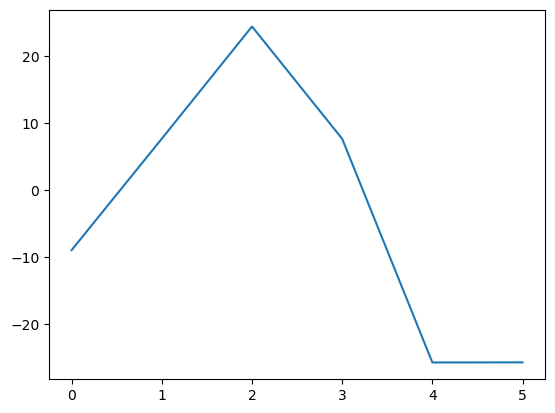

In [37]:
cam1_ts = np.load("./cam1_ts.npy")/1000000
cam2_ts = np.load("./cam2_ts.npy")/1000000

plt.plot(cam1_ts-cam2_ts)


#### Manual timestamps

In [ ]:
cam1_fn = np.array([1739461432213468817,
                    1739461674466071676,
                    1739461707246427225,
                    1739461744323333921,
                    1739461771631301163,
                    1739461801440064082])/1000000

cam1_img = np.array([1739461432213478993,
                     1739461674466082812,
                     1739461707246435801,
                     1739461744323342945,
                     1739461771631310379,
                     1739461801440074962])/1000000

cam2_fn = np.array([1739461856587684348,
                    1739461892295466039,
                    1739461925437439188,
                    1739461945978010036,
                    1739461966833438624,
                    1739461996298820297])/1000000

cam2_img = np.array([1739461856587692060,
                     1739461892295473271,
                     1739461925437444980,
                     1739461945978020596,
                     1739461966833445088,
                     1739461996298820297])/1000000

### Plot timestamps, fps

In [6]:
timestamps_and_fps = np.array((data['timestamps'],data['fps']))
np.save('./cam2_ts',timestamps_and_fps)

Text(0.5, 1.0, 'camera fps over time')

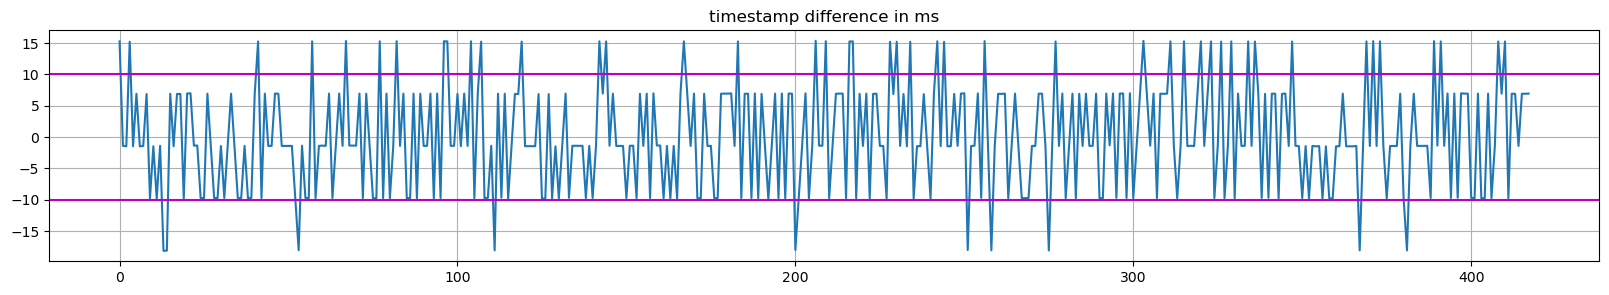

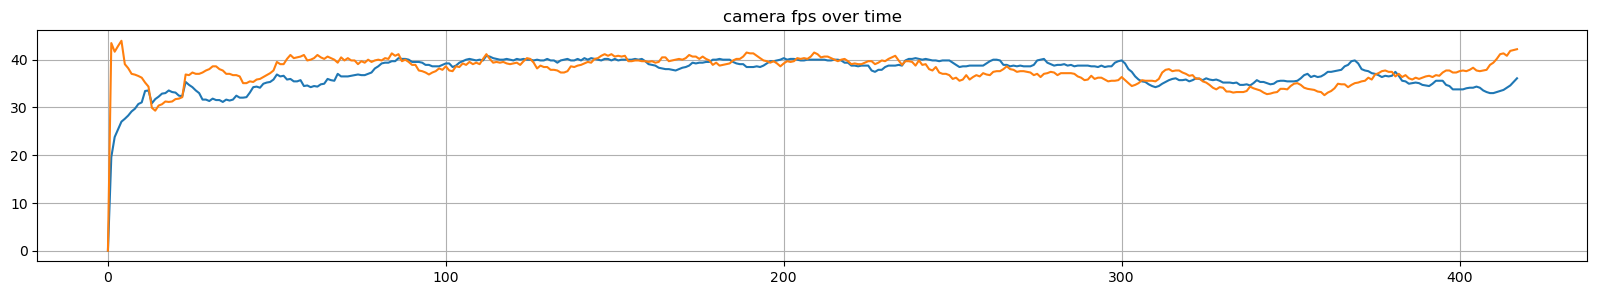

In [29]:
cam1_ts_fps = np.load('./cam1_ts.npy')
cam2_ts_fps = np.load('./cam2_ts.npy')

plt.figure(figsize=(20,3))
plt.plot(cam1_ts_fps[0]/1000000-cam2_ts_fps[0]/1000000)
plt.grid()
plt.axhline(y=10, c='m')
plt.axhline(y=-10, c='m')
plt.title('timestamp difference in ms')

plt.figure(figsize=(20,3))
plt.plot(cam1_ts_fps[1])
plt.plot(cam2_ts_fps[1])
plt.grid()
plt.title('camera fps over time')

### Async

In [69]:
async1 = np.load('./async_ts_1.npy')
async2 = np.load('./async_ts_2.npy')

end = min(async1.shape[1],async2.shape[1])

async1 = async1[0][:end]/1000000
async2 = async2[0][:end]/1000000

0 100 6781.966064453125
1 100 6748.64501953125
2 100 6715.30712890625
3 100 6681.97412109375
4 100 6648.63427734375
5 100 6615.303955078125
6 100 6581.97216796875
7 100 6548.64208984375
8 100 6515.296142578125
9 100 6498.618896484375
10 100 6465.30615234375
11 100 6398.63720703125
12 100 6365.284912109375
13 100 6331.97119140625
14 100 6315.30712890625
15 100 6281.97314453125
16 100 6248.619140625
17 100 6215.295166015625
18 100 6181.957275390625
19 100 6148.636962890625
20 100 6115.345947265625
21 100 6082.001953125
22 100 6048.68115234375
23 100 6032.01318359375
24 100 5998.676025390625
25 100 5965.33203125
26 100 5932.008056640625
27 100 5898.68212890625
28 100 5882.01513671875
29 100 5848.679931640625
30 100 5815.34228515625
31 100 5781.98828125
32 100 5748.6552734375
33 100 5715.34326171875
34 100 5682.01513671875
35 100 5648.744140625
36 100 5615.375244140625
37 100 5582.078125
38 100 5548.720947265625
39 100 5515.380126953125
40 100 5482.053955078125
41 100 5448.751220703125
42 

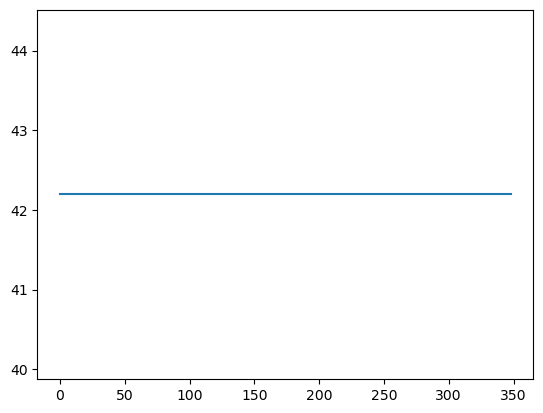

In [54]:
half_window = 100
diff_over_time = []

for i in range(half_window,len(async1)-half_window):

    diff_per_window = []
    for j in range(i-half_window,i+half_window):
        print(j,i,abs(async1[j]-async2[i]))
        diff_per_window.append([j,i,abs(async1[j]-async2[i])])

    diff_per_window = np.array(diff_per_window)
    one_sec_idx = np.argmin(diff_per_window,0)[2]
    diff = diff_per_window[one_sec_idx][0]-diff_per_window[one_sec_idx][1]
    diff_over_time.append(fps)


plt.plot(diff_over_time)

In [56]:
np.mean(diff_over_time)

42.194091796875

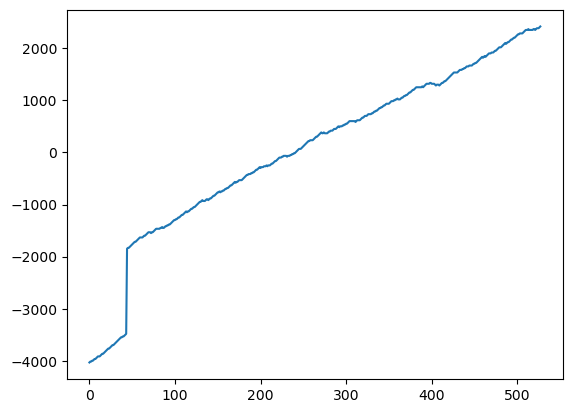

In [78]:
plt.plot(async1[21:]-async2[:-21])

In [77]:
diff_over_time = []
for shift in range(1,200):
    avg_diff = np.mean(async1[shift:]-async2[:-shift])
    print(avg_diff, shift)

-543.4513108747719 1
-515.1969255241659 2
-486.9306157709478 3
-458.6523688360092 4
-430.392687180463 5
-402.1210218116943 6
-373.8680271275369 7
-345.6029587497112 8
-317.3566993995949 9
-289.0675209625754 10
-260.76605156540427 11
-232.54542197683892 12
-204.31277374723064 13
-176.06801620911216 14
-147.77984367684925 15
-119.47940607410882 16
-91.16654979734493 17
-62.84120422478225 18
-34.50336453419811 19
-6.152879567137287 20
22.210378011067707 21
50.58645635673624 22
78.97541745262001 23
107.4090564546131 24
135.82395550676884 25
164.22004165795292 26
192.62915085832734 27
221.05133747825695 28
249.48680513822114 29
277.93541375015053 30
306.397334154048 31
334.84024419729207 32
363.29655137172966 33
391.7339118439017 34
420.184703307393 35
448.61653360288744 36
477.0617456436157 37
505.5205240566903 38
533.9601404526654 39
562.4132941045555 40
590.8799659548782 41
619.3603785287229 42
647.8545939931756 43
676.3626111927599 44
704.8514535086496 45
733.3541485462226 46
761.870847

In [71]:
async1.shape, async2.shape  

((549,), (549,))